In [1]:
# ===============================================
# Code Block 1 — Imports & Paths
# ===============================================
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

IN_DIR = "../data/processed"

CASE_FILE = os.path.join(IN_DIR, "case_features.csv")
RES_FILE  = os.path.join(IN_DIR, "resource_features.csv")
MUNI_FILE = os.path.join(IN_DIR, "municipality_features.csv")

OUT_CASE_FLAG = os.path.join(IN_DIR, "case_features_with_outliers.csv")
OUT_RES_FLAG  = os.path.join(IN_DIR, "resource_features_with_outliers.csv")
OUT_MUNI_FLAG = os.path.join(IN_DIR, "municipality_features_with_outliers.csv")

print("Loading datasets...")
case_df = pd.read_csv(CASE_FILE)
res_df  = pd.read_csv(RES_FILE)
muni_df = pd.read_csv(MUNI_FILE)

print(case_df.shape, res_df.shape, muni_df.shape)


Loading datasets...
(3183, 19) (64, 12) (5, 27)


In [2]:
# ===============================================
# Code Block 2 — Utility Functions
# ===============================================

def flag_iqr_outliers(series, k=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return (series < lower) | (series > upper)

def flag_zscore_outliers(series, z=3.0):
    std = series.std()
    if std == 0:
        return pd.Series([False]*len(series))
    zscore = (series - series.mean()) / std
    return np.abs(zscore) > z

def flag_mad_outliers(series, thresh=3.5):
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return pd.Series([False]*len(series))
    modified_z = 0.6745 * (series - median) / mad
    return np.abs(modified_z) > thresh

def iso_forest_flags(df, cols, contamination=0.02):
    model = IsolationForest(contamination=contamination, random_state=42)
    X = df[cols].fillna(0)
    preds = model.fit_predict(X)
    return preds == -1


In [3]:
# ===============================================
# Code Block 3 — Case Outlier Flags
# ===============================================

case_metrics = [
    "cycle_time_hours",
    "wait_time_hours",
    "processing_time_hours",
    "rework_count",
    "total_cost",
    "variant_length"
]

case_df["case_outlier"] = False

for col in case_metrics:
    if col in case_df.columns:
        case_df["case_outlier"] |= flag_iqr_outliers(case_df[col])
        case_df["case_outlier"] |= flag_mad_outliers(case_df[col])
        case_df["case_outlier"] |= flag_zscore_outliers(case_df[col])

print("Case outliers flagged:", case_df["case_outlier"].sum())


Case outliers flagged: 1218


In [4]:
# ===============================================
# Code Block 4 — Resource Outlier Flags
# ===============================================

res_metrics = [
    "n_events",
    "n_unique_cases",
    "n_distinct_activities",
    "avg_wait_before_event_hours",
    "avg_inter_event_hours",
    "avg_events_per_case",
    "handover_in",
    "handover_out"
]

res_df["res_outlier"] = False

for col in res_metrics:
    if col in res_df.columns:
        res_df["res_outlier"] |= flag_iqr_outliers(res_df[col])
        res_df["res_outlier"] |= flag_mad_outliers(res_df[col])
        res_df["res_outlier"] |= flag_zscore_outliers(res_df[col])

print("Resource outliers flagged:", res_df["res_outlier"].sum())


Resource outliers flagged: 28


In [5]:
# ===============================================
# Code Block 5 — Municipality Outlier Flags
# ===============================================

muni_metrics = [
    "performance_index",
    "avg_cycle_hours",
    "avg_wait_hours",
    "avg_cost",
    "avg_rework",
    "avg_handover_out",
    "handovers_per_case"
]

muni_df["muni_outlier"] = False

for col in muni_metrics:
    if col in muni_df.columns:
        muni_df["muni_outlier"] |= flag_iqr_outliers(muni_df[col])
        muni_df["muni_outlier"] |= flag_mad_outliers(muni_df[col])
        muni_df["muni_outlier"] |= flag_zscore_outliers(muni_df[col])

print("Municipality outliers flagged:", muni_df["muni_outlier"].sum())


Municipality outliers flagged: 1


In [6]:
# ===============================================
# Code Block 6 — Isolation Forest (optional)
# ===============================================

iso_cols = [c for c in case_metrics if c in case_df.columns]
case_df["iso_outlier"] = iso_forest_flags(case_df, iso_cols, contamination=0.02)

print("Isolation forest case outliers:", case_df["iso_outlier"].sum())


Isolation forest case outliers: 64


In [7]:
# ===============================================
# Code Block 7 — Save flagged datasets (no removals)
# ===============================================

case_df.to_csv(OUT_CASE_FLAG, index=False)
res_df.to_csv(OUT_RES_FLAG, index=False)
muni_df.to_csv(OUT_MUNI_FLAG, index=False)

print("Saved flagged datasets:")
print(OUT_CASE_FLAG)
print(OUT_RES_FLAG)
print(OUT_MUNI_FLAG)


Saved flagged datasets:
../data/processed\case_features_with_outliers.csv
../data/processed\resource_features_with_outliers.csv
../data/processed\municipality_features_with_outliers.csv


In [8]:
# ===============================================
# Visualization imports (run once)
# ===============================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

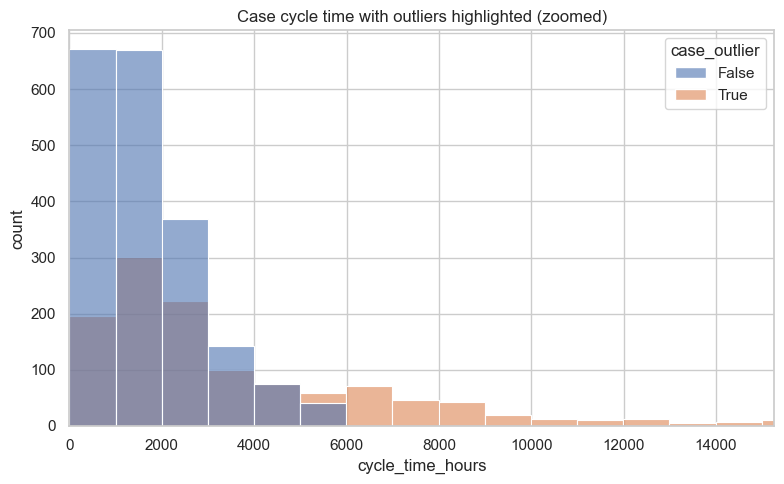

In [ ]:
# ===============================================
# Case outliers: histogram 
# ===============================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# choose zoom cutoff (change 0.99 → 0.95 if you want more zoom)
x_max = case_df["cycle_time_hours"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.histplot(
    data=case_df,
    x="cycle_time_hours",
    hue="case_outlier",
    bins=50,
    kde=False,
    multiple="layer",
    alpha=0.6
)
plt.title("Case cycle time with outliers highlighted (zoomed)")
plt.xlabel("cycle_time_hours")
plt.ylabel("count")
plt.xlim(0, x_max)   # <-- zoom here
plt.tight_layout()
plt.show()

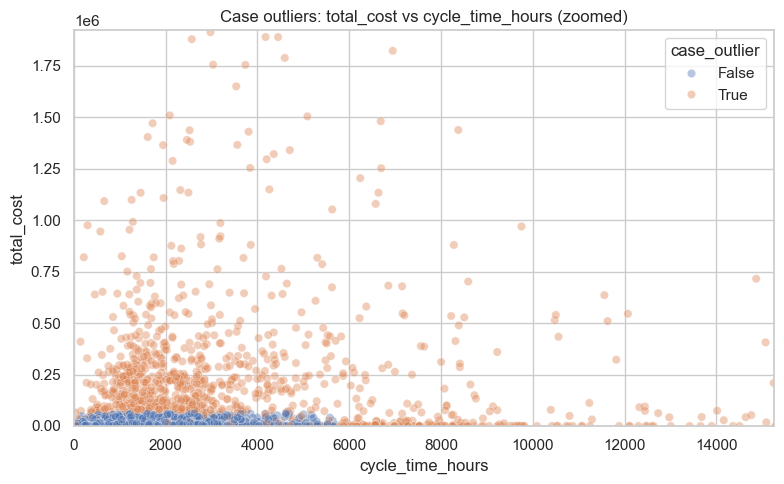

In [ ]:
# ===============================================
# Case outliers: total_cost vs cycle_time_hours 
# ===============================================

x_max = case_df["cycle_time_hours"].quantile(0.99)
y_max = case_df["total_cost"].quantile(0.99)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=case_df,
    x="cycle_time_hours",
    y="total_cost",
    hue="case_outlier",
    alpha=0.4
)
plt.title("Case outliers: total_cost vs cycle_time_hours (zoomed)")
plt.xlabel("cycle_time_hours")
plt.ylabel("total_cost")
plt.xlim(0, x_max)   # zoom x
plt.ylim(0, y_max)   # zoom y
plt.tight_layout()
plt.show()

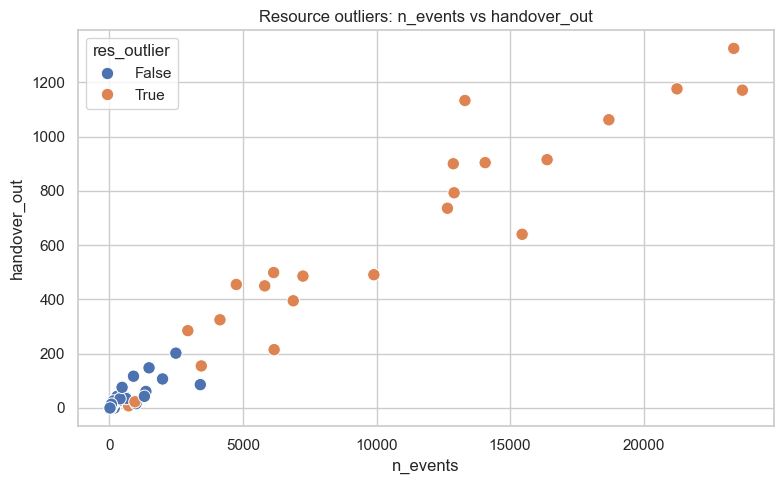

In [13]:
# ===============================================
# Resource outliers: events vs handover_out
# ===============================================
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=res_df,
    x="n_events",
    y="handover_out",
    hue="res_outlier",
    s=80
)
plt.title("Resource outliers: n_events vs handover_out")
plt.xlabel("n_events")
plt.ylabel("handover_out")
plt.tight_layout()
plt.show()